# Comparing satellite scenes — Sentinel-2, Landsat 8, MODIS

Goal: build a true-color image of the **Terra Nova Bay polynya** (Antarctica) from three different satellite missions and compare them.

The three missions trade resolution against coverage and revisit time:

| Sensor | Pixel size (visible) | Tile/granule size | Repeat over a given spot | How bands are delivered |
|---|---|---|---|---|
| **Sentinel-2** (ESA) | 10 m | ~110 × 110 km | every ~5 days | one `.jp2` file **per band** in a folder |
| **Landsat 8** (NASA/USGS) | 30 m | ~185 × 180 km | every 16 days | one `.TIF` file **per band** in a folder |
| **MODIS** (Aqua/Terra) | 250 m / 500 m / 1 km | ~2330 × 2030 km swath | **twice a day** | a single `.hdf` file with **all bands inside** |

The pattern: as pixels get bigger, each scene covers more area and revisits faster — so MODIS sees the polynya every day at 250–500 m, but for crisp 10 m detail you wait days for a Sentinel-2 pass. We'll plot the same area of interest from each.

## Setup
```bash
conda env create -f environment.yml
conda activate colin_polynya
conda install -c conda-forge pyhdf cartopy cmocean   # for MODIS
python -m ipykernel install --user --name colin_polynya
jupyter lab
```

## Data layout
```
sentinel2/<YYYYMMDD>/<...>_B02.jp2       (blue)
                     <...>_B03.jp2       (green)
                     <...>_B04.jp2       (red)
Landsat8/<...>_SR_B2.TIF                 (blue)
         <...>_SR_B3.TIF                 (green)
         <...>_SR_B4.TIF                 (red)
MODIS/<granule>/<...>.hdf                (one file, all bands)
```


## Imports and area of interest

We'll keep the **same lat/lon bounding box** for all three sensors so the plots are directly comparable. The Sentinel-2 tile happens to cover this box exactly; the Landsat 8 and MODIS scenes are larger and we'll crop them to match.


In [98]:
# pyproj on this machine needs an explicit data-dir under Jupyter.
# Adjust the path if you named the env differently.
import os
os.environ['PROJ_LIB']  = '/opt/anaconda3/envs/colin_polynya/share/proj'
os.environ['PROJ_DATA'] = '/opt/anaconda3/envs/colin_polynya/share/proj'
import pyproj
pyproj.datadir.set_data_dir('/opt/anaconda3/envs/colin_polynya/share/proj')

import re
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.font_manager import FontProperties

# A small reusable scale-bar helper used by every plot below.
# `length_m` is in axes data units, which are metres for both UTM and polar
# stereographic projections.
def add_scalebar(ax, length_m, label=None, loc='lower left', color='k'):
    if length_m is None:
        return
    if label is None:
        label = f'{length_m/1000:g} km' if length_m >= 1000 else f'{length_m:g} m'
    bar = AnchoredSizeBar(ax.transData, length_m, label, loc=loc,
                          pad=0.5, borderpad=0.8, sep=4, color=color, frameon=False,
                          size_vertical=length_m * 0.02,
                          fontproperties=FontProperties(size=10, weight='bold'))
    ax.add_artist(bar)

# Terra Nova Bay area of interest (lon_min, lat_min, lon_max, lat_max).
AOI_LATLON = (161.4, -75.8, 165.4, -74.7)


## 1. Sentinel-2 — the high-resolution view (10 m)

Sentinel-2 ships **one `.jp2` file per band** in a folder named by date. We:
1. Find the file for each band (B02 = blue, B03 = green, B04 = red).
2. Read the whole tile, downsampled, so it fits in memory and plots quickly.
3. **Stack** the three bands into one (H, W, 3) RGB image and apply a 2nd–98th percentile **stretch** so the contrast looks right.

**About the stretch:** raw pixel values over Antarctic ocean/ice sit way down in the low end of the 16-bit range. Without rescaling everything looks black. Mapping the 2nd percentile to 0 and 98th to 1 throws away the most extreme shadows and glints and uses the rest of the dynamic range.


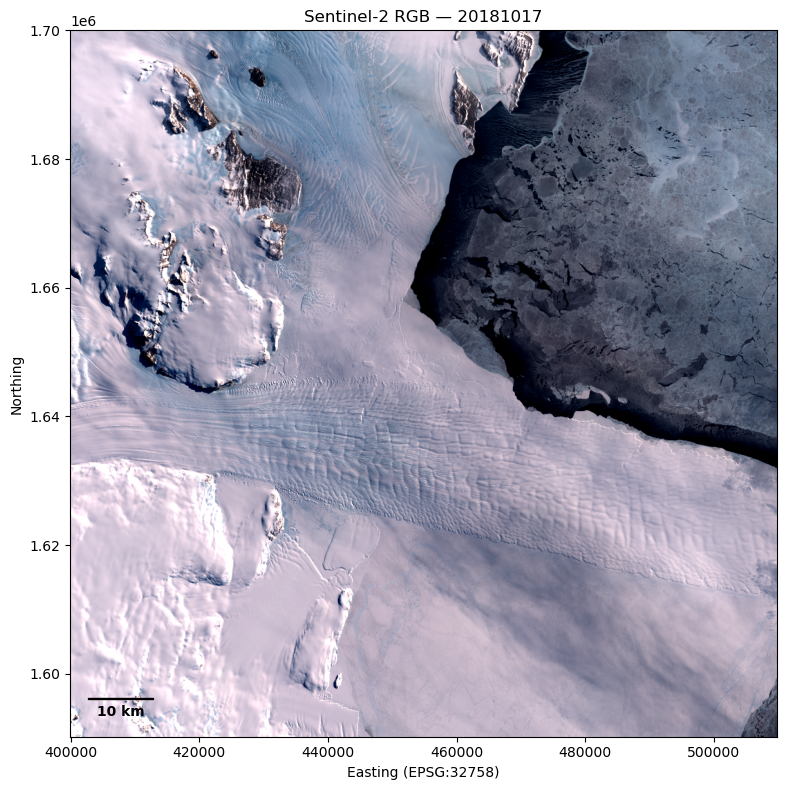

In [99]:
SENTINEL2_DIR = Path('sentinel2')

def find_s2_band(date, band):
    """Find a .jp2 file matching the given band code in sentinel2/<date>/."""
    matches = sorted(p for p in (SENTINEL2_DIR / date).glob('*.jp2') if band in p.name)
    if not matches:
        raise FileNotFoundError(f'No {band} file found in {SENTINEL2_DIR / date}')
    return matches[0]

def crs_from_tile(path):
    """Sentinel-2 tile name T<zone><lat_band>...  -> EPSG code for that UTM zone.

    Latitude bands C-M are southern hemisphere -> EPSG:327NN.
    Latitude bands N-X are northern hemisphere -> EPSG:326NN.
    We need this because rasterio's .jp2 reader doesn't always carry the CRS.
    """
    m = re.search(r'T(\d{2})([A-X])', Path(path).name)
    if not m:
        raise ValueError(f'No Sentinel-2 tile code in {path}')
    zone, band = int(m.group(1)), m.group(2)
    return f'EPSG:327{zone:02d}' if band <= 'M' else f'EPSG:326{zone:02d}'

def plot_sentinel2(date, downsample=10, scalebar_m=10_000):
    """Read full Sentinel-2 tile (downsampled), stack RGB, plot."""
    bands = []
    for b in ('B04', 'B03', 'B02'):  # R, G, B
        path = find_s2_band(date, b)
        crs = crs_from_tile(path)
        with rasterio.open(path) as src:
            out_h, out_w = src.height // downsample, src.width // downsample
            arr = src.read(1, out_shape=(out_h, out_w),
                           resampling=rasterio.enums.Resampling.average).astype(np.float32)
            bands.append(arr)
            extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    rgb = np.stack(bands, axis=-1)
    valid = rgb[rgb > 0]
    lo, hi = np.percentile(valid, [2, 98]) if valid.size else (0, 1)
    rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(rgb, extent=extent)
    add_scalebar(ax, scalebar_m, color='k')
    ax.set_title(f'Sentinel-2 RGB — {date}')
    ax.set_xlabel(f'Easting ({crs})'); ax.set_ylabel('Northing')
    plt.tight_layout(); plt.show()
    # Return tile bounds so MODIS/Landsat plots can match the extent
    return extent, crs

s2_extent, s2_crs = plot_sentinel2('20181017')
# s2_extent is (left, right, bottom, top) in UTM 58S metres


## 2. Landsat 8 — the middle ground (30 m)

Landsat 8's Surface Reflectance product (`LC08_L2SR_*`) ships **one GeoTIFF per band**, just like Sentinel-2 — but the band numbering is different and the file is already in **EPSG:3031** (Antarctic Polar Stereographic) instead of UTM.

| Landsat 8 band | Color | Wavelength |
|---|---|---|
| B2 | Blue  | ~482 nm |
| B3 | Green | ~561 nm |
| B4 | Red   | ~654 nm |

**Heads up:** the `Landsat8/` folder currently has **B2 (blue)** and **B4 (red)** but **no B3 (green)**. So we can't make a true-colour RGB until you download `..._SR_B3.TIF` from the same scene. For now we'll show the **B4 (red) band** with a colormap — it's the band with the highest contrast between water (dark) and ice (bright), so it's a natural single-band view of the polynya.

Once B3 is downloaded, the same `plot_landsat8()` function will switch to true-colour automatically (it falls back to single-band B4 only when B3 is missing).


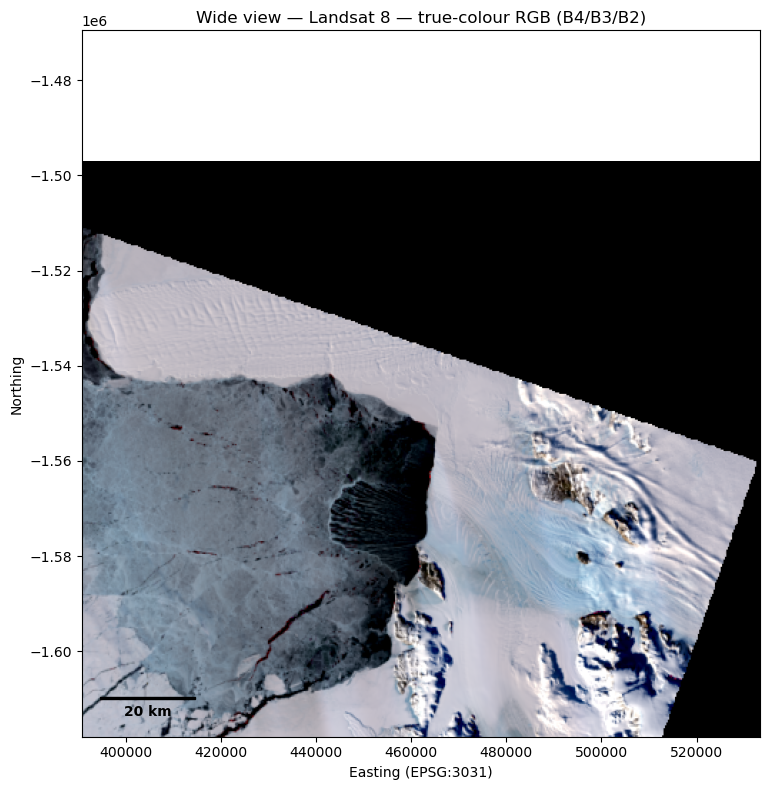

In [100]:
import cmocean

LANDSAT_DIR = Path('Landsat8')

def find_landsat_band(band):
    """Find LC08 .TIF for the given band code (e.g. 'B2', 'B3', 'B4')."""
    matches = sorted(p for p in LANDSAT_DIR.glob('*.TIF') if f'_{band}.TIF' in p.name)
    return matches[0] if matches else None

def read_landsat(band):
    """Read a Landsat 8 SR band as float reflectance (the L2SR product is
    stored as int16 with scale 0.0000275 + offset -0.2; here we only need
    the relative shape, so we cast to float and don't worry about the tiny
    offset)."""
    p = find_landsat_band(band)
    if p is None:
        return None, None
    with rasterio.open(p) as src:
        # Landsat is big (8000+ pixels per side) -- read at 1/10 to plot fast.
        h, w = src.height // 10, src.width // 10
        arr = src.read(1, out_shape=(h, w),
                       resampling=rasterio.enums.Resampling.average).astype(np.float32)
        crs = src.crs.to_string() if src.crs else 'EPSG:3031'
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    arr[arr == 0] = np.nan  # 0 is the L2SR fill value
    return arr, (crs, extent)

def plot_landsat8(box_lonlat=None, scalebar_m=20_000, title_prefix=''):
    """Plot Landsat 8 RGB if B2/B3/B4 are all on disk, else B4 with a colormap.

    `box_lonlat` is a (lon_min, lat_min, lon_max, lat_max) crop window — the
    whole Landsat scene is much bigger than the AOI, so we crop the axes
    after drawing.
    """
    B2, meta = read_landsat('B2')
    B3, _    = read_landsat('B3')
    B4, _    = read_landsat('B4')
    if B4 is None:
        raise FileNotFoundError('No B4 .TIF found in Landsat8/')
    crs, extent = meta

    fig, ax = plt.subplots(figsize=(8, 8))

    if B2 is not None and B3 is not None:
        # We have all three -> true-colour RGB, same recipe as Sentinel-2.
        rgb = np.stack([B4, B3, B2], axis=-1)
        valid = rgb[np.isfinite(rgb)]
        lo, hi = np.percentile(valid, [2, 98])
        rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)
        rgb = np.nan_to_num(rgb, nan=0.0)
        ax.imshow(rgb, extent=extent)
        title_extra = 'true-colour RGB (B4/B3/B2)'
    else:
        # Fall back to single-band B4 with the cmocean ice colormap.
        v = B4[np.isfinite(B4)]
        vmin, vmax = np.nanpercentile(v, [2, 98])
        im = ax.imshow(B4, extent=extent, cmap=cmocean.cm.ice, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='B4 (red, ~654 nm)')
        missing = ', '.join(b for b, x in zip(('B2', 'B3'), (B2, B3)) if x is None)
        title_extra = f'B4 only (missing {missing} -> no true-colour yet)'

    # Crop the plot to the requested lat/lon window.
    if box_lonlat is not None:
        lon_min, lat_min, lon_max, lat_max = box_lonlat
        x0, y0, x1, y1 = transform_bounds('EPSG:4326', crs,
                                          lon_min, lat_min, lon_max, lat_max)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)

    add_scalebar(ax, scalebar_m, color='k')
    ax.set_title(f'{title_prefix}Landsat 8 — {title_extra}')
    ax.set_xlabel(f'Easting ({crs})'); ax.set_ylabel('Northing')
    plt.tight_layout(); plt.show()

# Wide view: same AOI as Sentinel-2 / MODIS (the full polynya region).
plot_landsat8(box_lonlat=AOI_LATLON, scalebar_m=20_000, title_prefix='Wide view — ')


### Zoom in to the polynya / wind-row area

Same Landsat scene, just a tighter crop right onto the open-water and frazil-streak (wind-row) zone where Sentinel-2 showed the most structure. At 30 m per pixel Landsat doesn't quite resolve individual streaks the way Sentinel-2 does at 10 m, but the polynya boundary and the mosaic of new ice / open water are clearly visible.


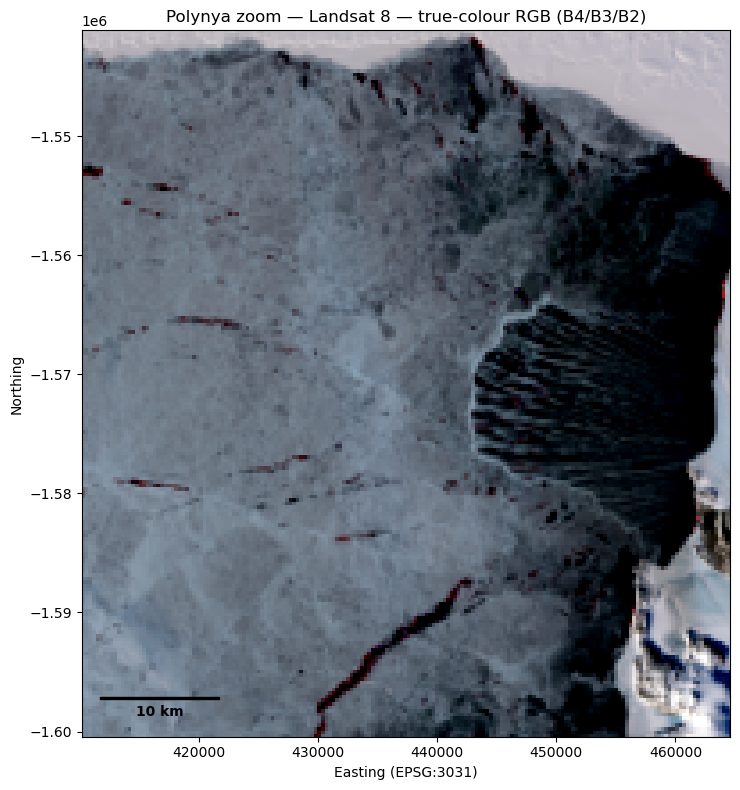

In [101]:
# Tighter window over the polynya. Adjust these four numbers to zoom in/out.
POLYNYA_LATLON = (163.7, -75.3, 165.2, -74.85)  # lon_min, lat_min, lon_max, lat_max
plot_landsat8(box_lonlat=POLYNYA_LATLON, scalebar_m=10_000, title_prefix='Polynya zoom — ')


## 3. MODIS — the wide view (500 m and 250 m, in one file)

MODIS is the odd one out. Two big differences from Sentinel-2 / Landsat:

1. **One file, many bands.** A MYD09 (Aqua) or MOD09 (Terra) Surface Reflectance file is a single `.hdf` containing every band as a named SDS (Scientific Data Set), plus `Latitude` and `Longitude` arrays giving the location of each pixel.
2. **Swath, not tile.** Pixels are stored in instrument scan order. The lat/lon arrays tell us where each pixel sits — they're not on a regular grid. We use `pcolormesh` with the lat/lon arrays directly so each pixel lands at its true location (no warping needed).

There's also a **terminator** caveat: surface-reflectance data is daytime-only, so a granule acquired at local night over our AOI is just empty here. The example files in `MODIS/` cover both cases — we'll plot the daytime one (`MYD09.A2018290.0820`).

### Two resolutions, side by side

The same `.hdf` file holds the same bands at **two resolutions** simultaneously:

| Resolution | Bands available | Best for |
|---|---|---|
| **250 m** | only B1 (red, ~645 nm) and B2 (NIR, ~858 nm) | sharp grayscale view |
| **500 m** | B1, B3 (blue), B4 (green), + B5–B7 | true-colour RGB |

So the tradeoff is **resolution vs. colour**. Below we plot both, side by side:
- left = 250 m B1 with the `cmocean.ice` colormap (sharper, monochrome)
- right = 500 m true-colour RGB (coarser, in colour)

### How `stack_rgb` is built

Same idea as Sentinel-2: stack three bands into an `(H, W, 3)` array. The only thing that's different is the band reading — instead of opening three files, we open one and call `.select('500m Surface Reflectance Band N')` three times.

| MODIS band | Color | Wavelength | Sentinel-2 / Landsat equivalent |
|---|---|---|---|
| 1 | Red   | ~645 nm | S2 B04 / L8 B4 |
| 4 | Green | ~555 nm | S2 B03 / L8 B3 |
| 3 | Blue  | ~469 nm | S2 B02 / L8 B2 |

Each band is independently 2/98%-stretched and gamma-corrected (γ=0.7) over the in-AOI pixels. Without per-band stretching the image gets a strong blue cast over snow because B3 is brighter than B1.


In [102]:
from pyhdf.SD import SD, SDC
import scipy.ndimage as ndi
import cartopy.crs as ccrs

MODIS_DIR = Path('MODIS')
MODIS_FILL = -28672  # MOD09 fill value

def find_modis_hdf(granule):
    """Resolve `granule` (folder under MODIS/, or 'folder/file.hdf') to a .hdf path."""
    p = MODIS_DIR / granule
    if p.is_file():
        return p
    matches = sorted(p.glob('*.hdf'))
    if not matches:
        raise FileNotFoundError(f'No .hdf file in {p}')
    return matches[0]

def _read_sds(mod, name):
    """Read one SDS, mask MOD09 fill (-28672), apply 0.0001 reflectance scale."""
    arr = mod.select(name)[:].astype(np.float32)
    arr[arr == MODIS_FILL] = np.nan
    return arr * 0.0001

def load_modis(granule, res='500m'):
    """Load surface-reflectance bands plus matching lat/lon at 250m or 500m.

    Lat/Lon SDS in the file are at 1 km, so we upsample by 4 (250m) or 2 (500m).
    Returns a dict with band arrays, 'lat', 'lon', and 'name'.
    """
    hdf = find_modis_hdf(granule)
    mod = SD(str(hdf), SDC.READ)
    if res == '250m':
        bands = ('Band 1', 'Band 2')
        zoom_factor = 4
    elif res == '500m':
        bands = ('Band 1', 'Band 4', 'Band 3')
        zoom_factor = 2
    else:
        raise ValueError(f'res must be "250m" or "500m", got {res!r}')
    out = {b: _read_sds(mod, f'{res} Surface Reflectance {b}') for b in bands}
    lat = ndi.zoom(mod.select('Latitude')[:],  zoom_factor, order=1)
    lon = ndi.zoom(mod.select('Longitude')[:], zoom_factor, order=1)
    h = min(lat.shape[0], next(iter(out.values())).shape[0])
    w = min(lat.shape[1], next(iter(out.values())).shape[1])
    out = {k: v[:h, :w] for k, v in out.items()}
    out['lat'], out['lon'] = lat[:h, :w], lon[:h, :w]
    out['name'] = Path(hdf).name
    return out

def stretch(ch, mask, pct=(2, 98), gamma=0.7):
    """2/98% percentile stretch + gamma. Stretches ch[mask] then applies to all of ch."""
    v = ch[mask & np.isfinite(ch)]
    if v.size == 0:
        return np.zeros_like(ch)
    lo, hi = np.nanpercentile(v, pct)
    return np.clip((ch - lo) / (hi - lo), 0, 1) ** gamma

def stack_rgb(B1, B4, B3, mask):
    """MODIS 500m bands 1/4/3 -> (H, W, 3) per-band-stretched RGB image."""
    R, G, Bl = stretch(B1, mask), stretch(B4, mask), stretch(B3, mask)
    return np.nan_to_num(np.stack([R, G, Bl], axis=-1), nan=0.0)

def crop_to_box(d, lon_min, lat_min, lon_max, lat_max):
    """Slice the swath dict's arrays down to rows/cols touching the AOI box."""
    in_box = ((d['lat'] > lat_min) & (d['lat'] < lat_max) &
              (d['lon'] > lon_min) & (d['lon'] < lon_max))
    rs, cs = np.any(in_box, axis=1), np.any(in_box, axis=0)
    r0, r1 = np.argmax(rs), len(rs) - np.argmax(rs[::-1])
    c0, c1 = np.argmax(cs), len(cs) - np.argmax(cs[::-1])
    out = {k: v[r0:r1, c0:c1] for k, v in d.items() if isinstance(v, np.ndarray)}
    out['name'] = d['name']
    out['mask'] = in_box[r0:r1, c0:c1]
    return out


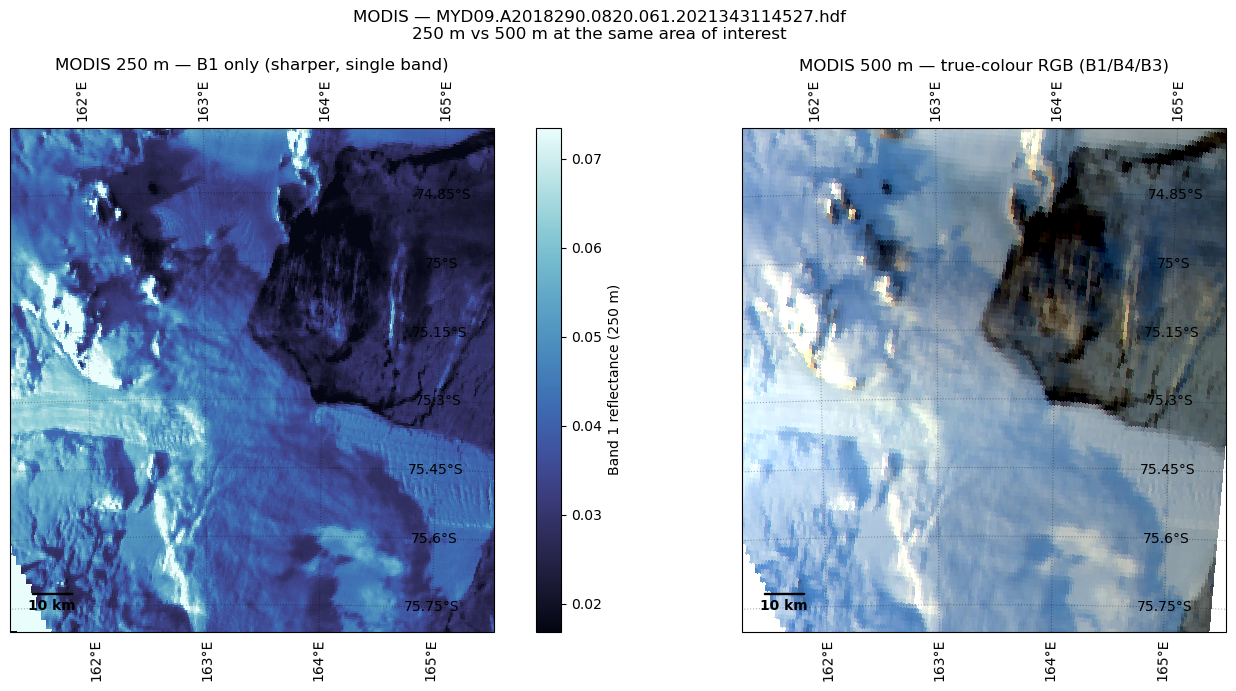

In [103]:
# Daytime granule over Terra Nova Bay
GRANULE = 'A2018290/MYD09.A2018290.0820.061.2021343114527.hdf'

lon_min, lat_min, lon_max, lat_max = AOI_LATLON
lon_c = (lon_min + lon_max) / 2

# --- 250 m (Band 1 only) and 500 m (RGB stack) loaded from the same .hdf ---
mod250 = crop_to_box(load_modis(GRANULE, res='250m'), *AOI_LATLON)
mod500 = crop_to_box(load_modis(GRANULE, res='500m'), *AOI_LATLON)

B1_250 = mod250['Band 1']
v = B1_250[mod250['mask'] & np.isfinite(B1_250)]
vmin, vmax = np.nanpercentile(v, [2, 98]) if v.size else (0, 1)

rgb500 = stack_rgb(mod500['Band 1'], mod500['Band 4'], mod500['Band 3'], mod500['mask'])

# --- Side-by-side plot ---
fig, axes = plt.subplots(
    1, 2, figsize=(15, 7),
    subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=lon_c)},
)
for ax in axes:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, color='k', alpha=0.3, linestyle=':')

# Left: 250 m B1 with the cmocean.ice colormap
mesh = axes[0].pcolormesh(mod250['lon'], mod250['lat'], B1_250,
                          transform=ccrs.PlateCarree(),
                          cmap=cmocean.cm.ice, vmin=vmin, vmax=vmax, shading='auto')
plt.colorbar(mesh, ax=axes[0], fraction=0.04, pad=0.06,
             label='Band 1 reflectance (250 m)')
add_scalebar(axes[0], 10_000, color='k')
axes[0].set_title('MODIS 250 m — B1 only (sharper, single band)')

# Right: 500 m true-colour RGB via pcolormesh + per-cell facecolors.
mesh2 = axes[1].pcolormesh(mod500['lon'], mod500['lat'], rgb500[..., 0],
                           transform=ccrs.PlateCarree(), shading='auto')
mesh2.set_facecolor(rgb500.reshape(-1, 3))
mesh2.set_edgecolor('face')
mesh2.update_scalarmappable = lambda: None  # keep per-cell RGB; don't recolour
add_scalebar(axes[1], 10_000, color='k')
axes[1].set_title('MODIS 500 m — true-colour RGB (B1/B4/B3)')

plt.suptitle(f'MODIS — {mod500["name"]}\n250 m vs 500 m at the same area of interest')
plt.tight_layout()
plt.show()


## How they compare at this AOI

|                | Sentinel-2 | Landsat 8 | MODIS 250 m | MODIS 500 m |
|---|---|---|---|---|
| Pixel size     | 10 m | 30 m | 250 m | 500 m |
| Pixels across the AOI (~110 km) | ~10,980 | ~3,660 | ~440 | ~220 |
| Bands at this res | B02, B03, B04 (and others) | B2, B3, B4 (and others) | B1, B2 only | B1–B7 |
| File layout    | one `.jp2` per band | one `.TIF` per band | all bands in one `.hdf` | (same `.hdf`) |
| Native CRS (this AOI) | UTM 58S (`EPSG:32758`) | Antarctic stereo (`EPSG:3031`) | swath (lat/lon arrays) | swath |
| Repeat cycle   | ~5 days | 16 days | twice daily | twice daily |
| Acquisition date used | 2018-10-17 | 2018-10-14 | 2018-10-17 | 2018-10-17 |

### When would you use which?

All three are passive optical sensors, so they **all need a clear (cloud-free) day** to see the surface. Beyond that, the choice is about resolution vs. revisit time:

- **Polynya boundary mapping at one moment in time** → Sentinel-2 (sharp, but you need a clear-sky day on the right pass).
- **Time-series of polynya area / open-water fraction** → MODIS 250 m B1 (an image of the polynya every single day, so you can pick the clear ones).
- **Long historical record** → Landsat (Landsat 1 launched in 1972; useful for decades-back comparisons, even if it's only every 16 days).

## Where to download data

All three datasets are free; you just need a (free) account on each portal.

### MODIS (Aqua / Terra)
- **Browse / preview:** [NASA Worldview](https://worldview.earthdata.nasa.gov/) — pan to your AOI, set the date, and toggle on the *MODIS Aqua/Terra Corrected Reflectance (True Color)* layers to scout for clear-sky days.
- **Download:** [Earthdata Search](https://search.earthdata.nasa.gov/) — enter rough coordinates (e.g. `-75, 163` for Terra Nova Bay) and a temporal range. Look for **MOD09** (Terra) or **MYD09** (Aqua) products under the *"Atmospherically Corrected Surface Reflectance 5-Min L2 Swath 250m, 500m, and 1km"* collection. Download the `.hdf` file (one file holds all bands).

### Landsat 8 / 9
- **Browse + download:** [USGS EarthExplorer](https://earthexplorer.usgs.gov/) — enter coordinates and a temporal range, then under *Data Sets* pick **Landsat → Landsat Collection 2 Level-2 → Landsat 8-9 OLI/TIRS C2 L2** and click *Results*. Download the individual band `.TIF` files for RGB: **B2** (blue), **B3** (green), **B4** (red).

### Sentinel-2
- **Browse + download:** [Copernicus Browser](https://browser.dataspace.copernicus.eu/) — navigate manually or use the *"Go to Place"* search with a nearby known identifier (e.g. *Drygalski Ice Tongue*). Under *Search → Sentinel-2*, pick the processing level (L1C and/or L2A is fine), enter the time range, and search. Tiles overlapping the AOI are highlighted; click one → information icon → *Download single files* → `GRANULE` → `<scene name>` (e.g. `L2A_T58CDB_A047230_20260322T212423`) → `IMG_DATA` → (sometimes `R10m`) → download the individual band `.jp2` files: **B02** (blue), **B03** (green), **B04** (red).

## Adding more scenes

- **Sentinel-2:** drop the three band files into `sentinel2/<YYYYMMDD>/` and call `plot_sentinel2('YYYYMMDD')`.
- **Landsat 8:** drop B2/B3/B4 `.TIF` files into `Landsat8/` and re-run the Landsat cell.
- **MODIS:** drop a `.hdf` into `MODIS/<granule>/` and change `GRANULE` in the MODIS cell to point at it.
